In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Cargamos y visualizamos los datos

In [18]:
# importamos el Dataset
import pandas as pd

# Al estar en la misma carpeta, solo necesitamos el nombre
path_local = "data/elnino.csv"

# 1. Definimos la lista con los nombres oficiales en minúsculas
columnas_minuscula = [
    'observation', 'year', 'month', 'day', 'date', 
    'latitude', 'longitude', 'zonal_winds', 'meridional_winds', 
    'humidity', 'air_temp', 'sst'
]

# 2. Leemos el archivo aplicando la nueva lista en minúsculas
df = pd.read_csv(
    path_local, 
    sep=',', 
    names=columnas_minuscula, 
    header=None, 
    skiprows=1
)

# Vamos a ver la forma del dataset para entender cuántas filas y columnas tenemos
dfshape = df.shape
print(f"El dataset tiene {dfshape[0]} filas y {dfshape[1]} columnas.")

# 3. Comprobamos la estructura
df.info()

El dataset tiene 178080 filas y 12 columnas.
<class 'pandas.DataFrame'>
RangeIndex: 178080 entries, 0 to 178079
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   observation       178080 non-null  int64  
 1   year              178080 non-null  int64  
 2   month             178080 non-null  int64  
 3   day               178080 non-null  int64  
 4   date              178080 non-null  int64  
 5   latitude          178080 non-null  float64
 6   longitude         178080 non-null  float64
 7   zonal_winds       178080 non-null  str    
 8   meridional_winds  178080 non-null  str    
 9   humidity          178080 non-null  str    
 10  air_temp          178080 non-null  str    
 11  sst               178080 non-null  str    
dtypes: float64(2), int64(5), str(5)
memory usage: 19.4 MB


In [19]:
# Vamos a ver la forma del dataset para entender cuántas filas y columnas tenemos
dfshape = df.shape
print(f"El dataset tiene {dfshape[0]} filas y {dfshape[1]} columnas.")

El dataset tiene 178080 filas y 12 columnas.


In [20]:
# Finalmente, un conteo de valores nulos por columna nos ayudará a identificar si necesitamos hacer limpieza de datos antes de entrenar nuestros modelos
print(df.isnull().sum())
df.head()

observation         0
year                0
month               0
day                 0
date                0
latitude            0
longitude           0
zonal_winds         0
meridional_winds    0
humidity            0
air_temp            0
sst                 0
dtype: int64


,observation,year,month,day,date,latitude,longitude,zonal_winds,meridional_winds,humidity,air_temp,sst
0,1,80,3,7,800307,-0.02,-109.46,-6.8,0.7,.,26.14,26.24
1,2,80,3,8,800308,-0.02,-109.46,-4.9,1.1,.,25.66,25.97
2,3,80,3,9,800309,-0.02,-109.46,-4.5,2.2,.,25.69,25.28
3,4,80,3,10,800310,-0.02,-109.46,-3.8,1.9,.,25.57,24.31
4,5,80,3,11,800311,-0.02,-109.46,-4.2,1.5,.,25.3,23.19


In [22]:
df.dtypes

observation           int64
year                  int64
month                 int64
day                   int64
date                  int64
latitude            float64
longitude           float64
zonal_winds             str
meridional_winds        str
humidity                str
air_temp                str
sst                     str
dtype: object

In [23]:
# Limpiamos y formateamos los datos

# 1. Eliminar duplicados si los hay
df = df.drop_duplicates()

# 2. Reemplazamos los puntos aislados por valores nulos reales (NaN)
df = df.replace('.', np.nan)

# 3. Creamos una fecha real combinando las columnas de año, mes y día
df['complete_date'] = pd.to_datetime(
    (df['year'] + 1900).astype(str) + '-' + 
    df['month'].astype(str) + '-' + 
    df['day'].astype(str)
)

# 4. Reemplazamos la antigua columna 'date' por esta nueva con el formato correcto
df['date'] = df['complete_date'].dt.strftime('%Y-%m-%d')

# 5. Forzamos a que las columnas físicas sean numéricas
columnas_numericas = ['latitude', 'longitude', 'zonal_winds', 'meridional_winds', 'sst']
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [25]:
df.dtypes

observation                  int64
year                         int64
month                        int64
day                          int64
date                           str
latitude                   float64
longitude                  float64
zonal_winds                float64
meridional_winds           float64
humidity                       str
air_temp                       str
sst                        float64
complete_date       datetime64[us]
dtype: object

# Hypótesis de trabajo:

El aumento de la temperatura superficial del mar **(SST)** aleja a ciertas especies marinas comerciales de sus zonas habituales de captura. 

# Objetivo: 

Construir un Sistema de Alerta Temprana que clasifica  eventos de riesgo extremo, para la Cadena de Suministro o Aseguradoras. Las empresas conserveras o de distribución pesquera pueden usar el modelo para anticipar con 15 o 30 días de margen la escasez de suministro y renegociar contratos de manera temprana.

In [26]:
# Lista de columnas a eliminar 
columnas_a_eliminar = ['date', 'day', 'year', 'month', 'humidity', 'air_temp']

df = df.drop(columns=columnas_a_eliminar, errors='ignore')

# Creamos la variable alert_anomaly

In [27]:
# 1. Calculamos el valor de temperatura que marca el percentil 85 (Corregido sin df_)
umbral_percentil =df['sst'].quantile(0.85)

print(f"El umbral del percentil 85 es: {umbral_percentil:.2f} °C")

# 2. Creamos el target basándonos en ese umbral dinámico
df['alert_anomaly'] = np.where(df['sst'] > umbral_percentil, 1, 0)

El umbral del percentil 85 es: 29.55 °C


In [28]:
# Ver el recuento absoluto y el porcentaje de desbalanceo
print(df['alert_anomaly'].value_counts())
print(df['alert_anomaly'].value_counts(normalize=True) * 100)

alert_anomaly
0    154317
1     23763
Name: count, dtype: int64
alert_anomaly
0    86.655997
1    13.344003
Name: proportion, dtype: float64


C:\Users\naila\AppData\Local\Temp\ipykernel_6280\754511056.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='alert_anomaly', data=df, palette='viridis')


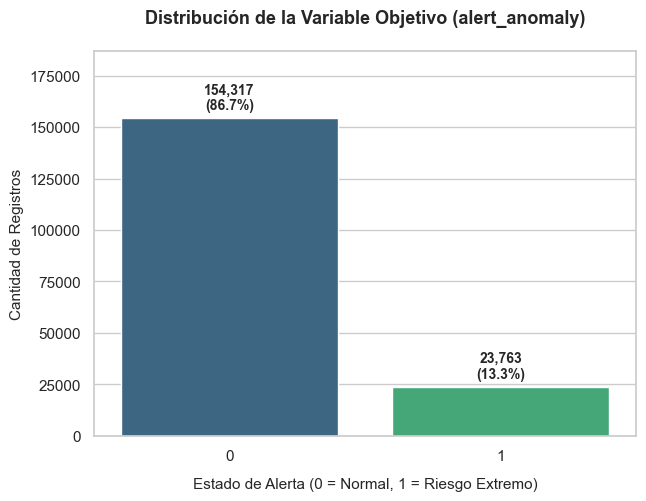

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el tamaño y estilo
plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")

# 2. Crear el gráfico capturando el eje (ax)
# Cambia 'df' por el nombre real de tu DataFrame
ax = sns.countplot(x='alert_anomaly', data=df, palette='viridis')

# 3. Calcular el total de registros para obtener los porcentajes
total_registros = len(df)

# 4. Recorrer las barras para pintar la cifra exacta y el porcentaje
for p in ax.patches:
    # Obtener la altura de la barra (la cantidad de filas)
    cantidad = int(p.get_height())
    # Calcular el porcentaje respecto al total
    porcentaje = f"{100 * cantidad / total_registros:.1f}%"
    
    # Formatear el texto que se mostrará (ej: "151,368\n(85.0%)")
    texto = f"{cantidad:,}\n({porcentaje})"
    
    # Colocar el texto justo encima de cada barra
    ax.annotate(
        texto, 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', 
        va='center', 
        xytext=(0, 15), 
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

# 5. Ajustar etiquetas y títulos limpios
plt.title('Distribución de la Variable Objetivo (alert_anomaly)', fontsize=13, pad=20, fontweight='bold')
plt.xlabel('Estado de Alerta (0 = Normal, 1 = Riesgo Extremo)', fontsize=11, labelpad=10)
plt.ylabel('Cantidad de Registros', fontsize=11)

# Ampliar un poco el límite del eje Y para que el texto de las barras no se corte
plt.ylim(0, total_registros * 1.05)

# 6. Mostrar el gráfico sin textos residuales de matplotlib
plt.show()

In [30]:
#  Guardar el archivo definitivo para los modelos
df.to_csv('dataset_elnino_final.csv', index=False)

print("✅ Archivo 'dataset_elnino_final.csv' creado con éxito.")
print(f"📊 Shape final: {df.shape}")
print(f"📋 Columnas resultantes: {list(df.columns)}")

✅ Archivo 'dataset_elnino_final.csv' creado con éxito.
📊 Shape final: (178080, 8)
📋 Columnas resultantes: ['observation', 'latitude', 'longitude', 'zonal_winds', 'meridional_winds', 'sst', 'complete_date', 'alert_anomaly']


In [32]:
# visualización con las columnas de variables temporales que hemos creado con SQL (notebook: sql_to_python)

df.head()

,observation,latitude,longitude,zonal_winds,meridional_winds,sst,complete_date,alert_anomaly
0,1,-0.02,-109.46,-6.8,0.7,26.24,1980-03-07,0
1,2,-0.02,-109.46,-4.9,1.1,25.97,1980-03-08,0
2,3,-0.02,-109.46,-4.5,2.2,25.28,1980-03-09,0
3,4,-0.02,-109.46,-3.8,1.9,24.31,1980-03-10,0
4,5,-0.02,-109.46,-4.2,1.5,23.19,1980-03-11,0
